<h1>Verification </h1>
<p>
<h3>Things to verify </h3>  

- [ ] Basic verification     
- [ ] Check that timestep size (day, month, etc) has no influence on total material in system        
- [ ] Check why int overflow errors occur and fix        
<h3> Things to add </h3>

- [x] Init the model with 10**-7 H**+ concentration per cell          
- [ ] Add function to get/transform GLiM data      
- [ ] Add model funcionality to neutralise with carbonate materials     
- [x] Add model progress bar
</p>

In [ ]:
from funcs import mindat_collector, vecor_rasterisation, flo1k_prep, hydir_IDs, filter_mines_with_buffer, bool_to_int, cleanup_and_metadata, add_time
from funcs import estimate_ore
import matplotlib.pyplot as plt
from classes import AMDModel
import numpy as np
import xarray as xr

In [2]:
def test_dataset(freq, time):
    Q = np.zeros((3, 3), dtype = int)
    Q[0, 0] = 1
    Q[0, 1] = 2
    Q[0, 2] = 1
    Q[1, 0] = 1
    Q[1, 1] = 3
    Q[1, 2] = 4
    Q[2, 0] = 2
    Q[2, 1] = 3
    Q[2, 2] = 7
    source = np.zeros((3, 3), dtype = int)
    source[0, 0] = 1
    source[0, 2] = 1

    ID = np.zeros((3, 3), dtype =int)
    ID[0, 0] = 1
    ID[0, 1] = 2
    ID[0, 2] = 3
    ID[1, 0] = 4
    ID[1, 1] = 5
    ID[1, 2] = 6
    ID[2, 0] = 7
    ID[2, 1] = 8
    ID[2, 2] = 9

    outID = np.zeros((3, 3), dtype =int)
    outID[0, 0] = 2
    outID[0, 1] = 5
    outID[0, 2] = 6
    outID[1, 0] = 7
    outID[1, 1] = 6
    outID[1, 2] = 9
    outID[2, 0] = 8
    outID[2, 1] = 9
    outID[2, 2] = -1

    ore = np.zeros((3, 3), dtype = int)
    ore[0, 0] = 2700
    ore[0, 2] = 2700
    ore[2, 1] = 2700

    ds = xr.DataArray(Q, dims = ["i", "j"]).to_dataset(name = "qav")
    da_ID = xr.DataArray(ID, dims = ["i", "j"])
    da_outID = xr.DataArray(outID, dims = ["i", "j"])
    da_source = xr.DataArray(source, dims = ["i", "j"])
    da_ore = xr.DataArray(ore, dims = ["i", "j"])
    ds["ID"] = da_ID
    ds["outID"] = da_outID
    ds["source"] = da_source
    ds["ore"] = da_ore
    ds = ds.rename_dims({"i": "lat", "j": "lon"})

    ds = add_time(ds, 2015, freq, time)
    return ds

In [3]:
ds1 = test_dataset(56, "W")

In [4]:
model_test1 = AMDModel(ds1, "week")
model_test1.dataset = model_test1.dataset.assign_coords({"lon": range(0, 3), "lat": range(0,3)})
model_test1.run()

56it [00:14,  3.94it/s]


In [5]:
ds2  = test_dataset(12, "MS")
model_test2 = AMDModel(ds2, "month")
model_test2.dataset = model_test2.dataset.assign_coords({"lon": range(0, 3), "lat": range(0,3)})
model_test2.run()

12it [00:02,  4.04it/s]


In [6]:
model_test1.dataset["ferric_iron"][11].sum()


<xarray.DataArray 'ferric_iron' ()> Size: 8B
array(7132.94493885)
Coordinates:
    time     datetime64[ns] 8B 2015-03-22
Attributes:
    units:        mol/timestep
    description:  Fe³⁺

In [7]:
model_test2.dataset["ferric_iron"][11].sum()

<xarray.DataArray 'ferric_iron' ()> Size: 8B
array(30994.34407951)
Coordinates:
    time     datetime64[ns] 8B 2015-12-01
Attributes:
    units:        mol/timestep
    description:  Fe³⁺

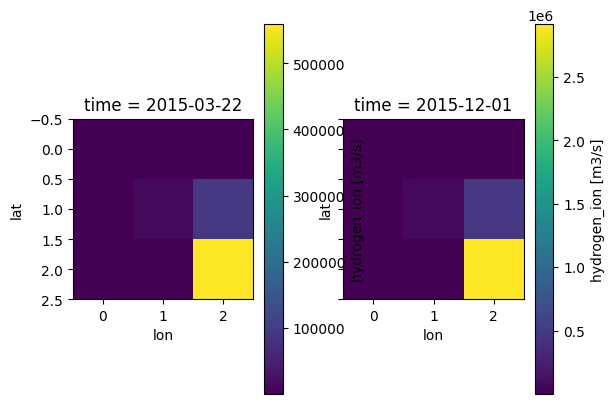

In [8]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, sharey= True)
model_test2.dataset["hydrogen_ion"][11].plot(ax = ax2)
model_test1.dataset["hydrogen_ion"][11].plot(ax = ax1)
ax1.set_aspect("equal")
ax2.set_aspect("equal")
fig.gca().invert_yaxis()

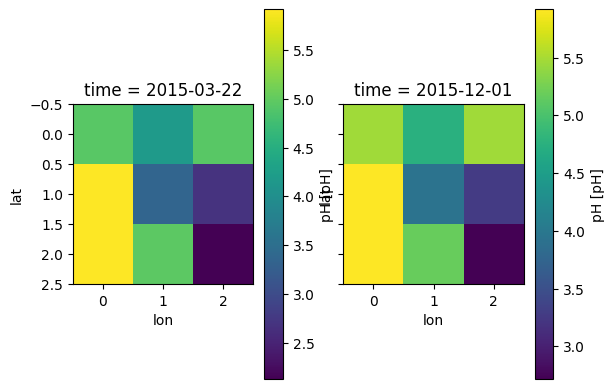

In [9]:
model_test1.output_calc()
model_test2.output_calc()
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, sharey= True)
model_test2.dataset["pH"][11].plot(ax = ax2)
model_test1.dataset["pH"][11].plot(ax = ax1)
ax1.set_aspect("equal")
ax2.set_aspect("equal")
fig.gca().invert_yaxis()

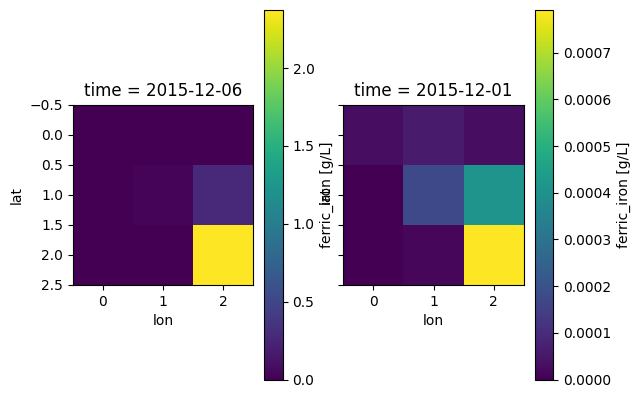

In [10]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, sharey= True)
model_test2.dataset["ferric_iron"][11].plot(ax = ax2)
model_test1.dataset["ferric_iron"][48].plot(ax = ax1)
ax1.set_aspect("equal")
ax2.set_aspect("equal")
fig.gca().invert_yaxis()

In [11]:
ds3 = test_dataset(365, "D")
model_test3 = AMDModel(ds3, "day")
model_test3.dataset = model_test3.dataset.assign_coords({"lon": range(0, 3), "lat": range(0,3)})
model_test3.run()

365it [01:31,  3.99it/s]


In [12]:
model_test3.output_calc()

In [13]:
print(model_test1.dataset["ferric_iron"][55].sum().values)
print(model_test2.dataset["ferric_iron"][11].sum().values)
print(model_test3.dataset["ferric_iron"][364].sum().values)

4.901713603280634
0.001495256161742808
104611381.88306837


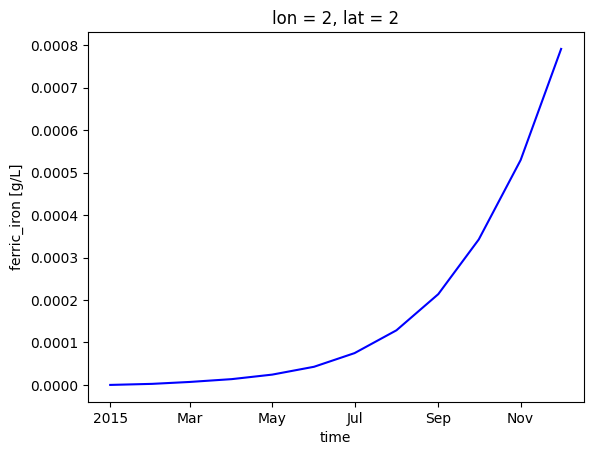

In [ ]:
fig, ax = plt.subplots()
model_test1.dataset["ferric_iron"].sel(lat = 2, lon = 2).plot(ax = ax, color = "r")
model_test2.dataset["ferric_iron"].sel(lat = 2, lon = 2).plot(ax = ax, color = "b")
model_test3.dataset["ferric_iron"].sel(lat = 2, lon = 2).plot(ax = ax, color = "orange")